In [1]:
import json
import pickle
import re
from pathlib import Path

import numpy as np
import pandas as pd

%matplotlib inline 

import matplotlib.pyplot as plt
# import seaborn as sns

In [2]:
results_path = Path('linear_readout_weights')

val_outfiles = list(results_path.glob('*_val_results.json'))

results = []
for outfile in val_outfiles:
    layer_idx = outfile.stem.split('_')[1]
    with open(outfile, 'r') as f:
        val_results = json.load(f)
    val_results['layer_idx'] = layer_idx
    results.append(val_results)

results_df = pd.DataFrame(results)

In [21]:
results_df

,val_loss,val_acc,val_labels,val_preds,layer_idx
0,2.859484,0.175228,"[26, 2, 47, 19, 60, 44, 55, 0, 29, 10, 39, 21,...","[25, 1, 47, 28, 64, 46, 54, 35, 30, 11, 38, 19...",0
1,2.649825,0.192646,"[26, 2, 47, 19, 60, 44, 55, 0, 29, 10, 39, 21,...","[25, 33, 48, 34, 45, 65, 55, 36, 34, 10, 39, 2...",1
2,2.754322,0.168570,"[26, 2, 47, 19, 60, 44, 55, 0, 29, 10, 39, 21,...","[10, 1, 48, 33, 46, 65, 58, 36, 34, 11, 39, 23...",2
3,2.798044,0.181727,"[26, 2, 47, 19, 60, 44, 55, 0, 29, 10, 39, 21,...","[10, 1, 46, 33, 46, 44, 52, 36, 0, 11, 39, 23,...",3
4,2.797756,0.174762,"[26, 2, 47, 19, 60, 44, 55, 0, 29, 10, 39, 21,...","[10, 1, 47, 31, 45, 62, 55, 34, 31, 17, 39, 23...",4


In [ ]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def mean_abs_error(y_true, y_pred):
    uncorr_error = np.mean(np.abs(y_true - y_pred))
    # replace anything in corr error that is greater than 180 with 360 - it
    act_error = np.abs(np.mod(y_true - y_pred + 180, 360) - 180)
    return np.mean(np.minimum(uncorr_error, act_error))

def label_to_azim(label):
    return label * 5


In [22]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=100):
    n = len(y_true)
    stats = []
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        stats.append(metric_fn(y_true[idx], y_pred[idx]))
    return np.mean(stats), np.std(stats)

In [24]:
results = []

for layer, g in results_df.groupby('layer_idx'):
    # print(g['val_labels'])
    y_true = np.array(g['val_labels'].item()).astype(np.int64)
    y_pred = np.array(g['val_preds'].item()).astype(np.int64)
    # print(y_true)
    # print(y_pred)
    acc, acc_err = bootstrap_metric(y_true, y_pred, accuracy)

    azim_true = np.array([label_to_azim(label) for label in y_true])
    azim_pred = np.array([label_to_azim(pred) for pred in y_pred])
    # print(azim_true)
    # print(azim_pred)
    mae, mae_err = bootstrap_metric(azim_true, azim_pred, mean_abs_error)
    results.append({
        'layer_idx': layer,
        'acc_mean': acc,
        'acc_err': acc_err,
        'deg_mean': mae,
        'deg_err': mae_err
    })

boot_df = pd.DataFrame(results)

In [25]:
boot_df

,layer_idx,acc_mean,acc_err,deg_mean,deg_err
0,0,0.175233,0.001693,14.865812,0.094764
1,1,0.192537,0.001744,13.928729,0.108311
2,2,0.168514,0.001532,16.490296,0.118303
3,3,0.181877,0.001670,14.614160,0.103653
4,4,0.174884,0.001641,14.244359,0.096152


In [28]:
len(y_true) 

47808

Text(0, 0.5, 'Accuracy (%)')

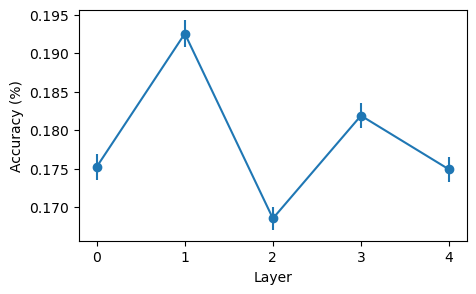

In [26]:
# plot avg diffs by layer
plt.figure(figsize=(5, 3))
plt.errorbar(
    boot_df['layer_idx'], boot_df['acc_mean'],
    yerr=boot_df['acc_err'], fmt='-o'
)
plt.xlabel('Layer')
plt.ylabel('Accuracy (%)')

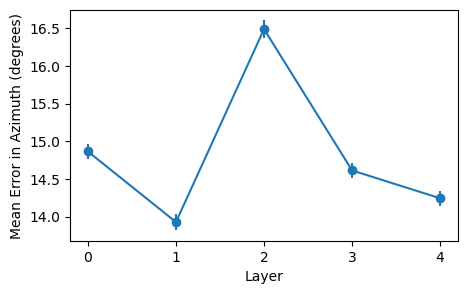

In [27]:
# plot accuracy by layer
plt.figure(figsize=(5, 3))
plt.errorbar(
    boot_df["layer_idx"], boot_df["deg_mean"],
    yerr=boot_df["deg_err"], fmt='-o'
)
plt.xlabel('Layer')
plt.ylabel('Mean Error in Azimuth (degrees)')
plt.show()
